In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchquantum.plugin.cuquantum import *
from torchquantum.operator.standard_gates import *

In [2]:
import torchquantum as tq
import torchquantum.functional as tqf
q_dev = tq.QuantumDevice(n_wires=1)
q_dev.reset_states(bsz=1)
print(f"all zero state: {q_dev}")
tqf.h(q_dev, wires=0)
print(f"after h gate: {q_dev}")

tqf.rx(q_dev, wires=0, params=[0.3])

print(f"after rx gate: {q_dev}")

all zero state:  class: QuantumDevice 
 device name: default 
 number of qubits: 1 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[1.+0.j, 0.+0.j]], dtype=complex64)
after h gate:  class: QuantumDevice 
 device name: default 
 number of qubits: 1 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[0.70710677+0.j, 0.70710677+0.j]], dtype=complex64)
after rx gate:  class: QuantumDevice 
 device name: default 
 number of qubits: 1 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[0.6991667-0.10566872j, 0.6991667-0.10566872j]], dtype=complex64)


In [3]:
# Method 1: Using cuquantum ParameterizedQuantumCircuit
n_wires = 1

# Create a parameterized quantum circuit with cuquantum backend
circuit = ParameterizedQuantumCircuit(n_wires=n_wires, n_input_params=0)


# Add gates to the circuit
circuit.append_gate(Hadamard, wires=0)
circuit.append_gate(RX, wires=0, fixed_params=[0.3])

backend = CuTensorNetworkBackend(TNConfig(num_hyper_samples=1))
sampling = QuantumSampling(circuit, backend, 100)
print(sampling())

[{'0': np.int64(47), '1': np.int64(53)}]


Traditional TorchQuantum sampling:


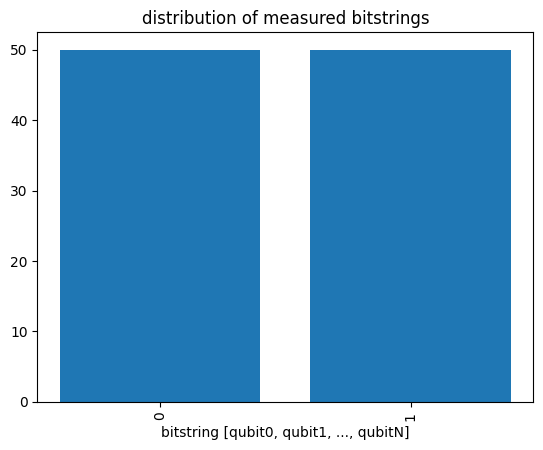

Traditional result: [OrderedDict([('0', 50), ('1', 50)])]


In [4]:
# For comparison: Traditional TorchQuantum sampling approach
print("Traditional TorchQuantum sampling:")
q_dev_compare = tq.QuantumDevice(n_wires=1)
q_dev_compare.reset_states(bsz=1)

# Apply the same gates
tqf.h(q_dev_compare, wires=0)
tqf.rx(q_dev_compare, wires=0, params=[0.3])

# Sample using TorchQuantum's measure function
traditional_samples = tq.measure(q_dev_compare, n_shots=100, draw_id=0)
print(f"Traditional result: {traditional_samples}")

# The results should be statistically similar (both are sampling from the same quantum state)

In [16]:
# Gradient-based optimization with cuQuantum
print("=== Gradient-Based Optimization with cuQuantum ===")

# Reset and create a new circuit for optimization
n_wires = 8
circuit_opt = ParameterizedQuantumCircuit(n_wires=n_wires, n_input_params=0, n_trainable_params=16)
for layer in range(4):
    for wire in range(n_wires):
        circuit_opt.append_gate(Hadamard, wires=wire)
    for wire in range(n_wires-1):
        circuit_opt.append_gate(CNOT, wires=[wire, wire+1])
    for wire in range(n_wires):
        circuit_opt.append_gate(RX, wires=wire, trainable_idx=layer + wire)

# Initialize parameter randomly
circuit_opt.set_trainable_params(torch.randn(16))

# Create optimizer - FIX: Wrap trainable_params in a list!
print("Parameters shape:", circuit_opt.trainable_params.shape)
print("Parameters type:", type(circuit_opt.trainable_params))
optimizer = torch.optim.Adam([circuit_opt.trainable_params], lr=0.01)  # Note the []

# Target: maximize amplitude of specific state
target_bitstring = "00000000"  # All zeros state for 8 qubits
backend_opt = CuTensorNetworkBackend(TNConfig(num_hyper_samples=1))
amplitude_module_opt = QuantumAmplitude(circuit_opt, backend_opt, [target_bitstring])

print(f"Starting optimization to reach |{target_bitstring}⟩ state...")
print("Initial parameters (first few):", circuit_opt.trainable_params[:5].detach().numpy())

# Optimization loop
for step in range(50):
    optimizer.zero_grad()
    
    # Compute amplitude and loss
    amplitude = amplitude_module_opt()
    loss = 1 - amplitude.abs()  # Minimize this to maximize amplitude
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if step % 5 == 0:
        print(f"Step {step:2d}: amplitude={amplitude.abs().item():.6f}, loss={loss.item():.6f}")
        print(f"         gradients norm: {circuit_opt.trainable_params.grad.norm().item():.6f}")

print(f"\nFinal amplitude for |{target_bitstring}⟩: {amplitude.abs().item():.6f}")


=== Gradient-Based Optimization with cuQuantum ===
Parameters shape: torch.Size([16])
Parameters type: <class 'torch.nn.parameter.Parameter'>
Starting optimization to reach |00000000⟩ state...
Initial parameters (first few): [1.5437146  0.9655495  0.60008085 0.628393   0.94734263]
Step  0: amplitude=0.363092, loss=0.636908
         gradients norm: 0.646618
Step  0: amplitude=0.363092, loss=0.636908
         gradients norm: 0.646618
Step  5: amplitude=0.380316, loss=0.619684
         gradients norm: 0.258001
Step  5: amplitude=0.380316, loss=0.619684
         gradients norm: 0.258001
Step 10: amplitude=0.403115, loss=0.596885
         gradients norm: 0.329096
Step 10: amplitude=0.403115, loss=0.596885
         gradients norm: 0.329096
Step 15: amplitude=0.426379, loss=0.573621
         gradients norm: 0.233575
Step 15: amplitude=0.426379, loss=0.573621
         gradients norm: 0.233575
Step 20: amplitude=0.451434, loss=0.548566
         gradients norm: 0.279891
Step 20: amplitude=0.4514

In [19]:
class QModel(tq.QuantumModule):
    def __init__(self):
        super().__init__()
        self.n_wires = 2
        self.u3_0 = tq.U3(has_params=True, trainable=True)
        self.u3_1 = tq.U3(has_params=True, trainable=True)
        self.cu3_0 = tq.CU3(has_params=True, trainable=True)
        self.cu3_1 = tq.CU3(has_params=True, trainable=True)
        self.u3_2 = tq.U3(has_params=True, trainable=True)
        self.u3_3 = tq.U3(has_params=True, trainable=True)
        #self.random_layer = tq.RandomLayer(n_ops=10,
        #                                   wires=list(range(self.n_wires)))

    def forward(self, q_device: tq.QuantumDevice):
        self.u3_0(q_device, wires=0)
        self.u3_1(q_device, wires=1)
        self.cu3_0(q_device, wires=[0, 1])
        self.u3_2(q_device, wires=0)
        self.u3_3(q_device, wires=1)
        self.cu3_1(q_device, wires=[1, 0])
        #self.random_layer(q_device)


q_dev = tq.QuantumDevice(n_wires=2)
q_dev.reset_states(bsz=3)
print(q_dev)

model = QModel()
model(q_dev)
print(q_dev)

 class: QuantumDevice 
 device name: default 
 number of qubits: 2 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]], dtype=complex64)


AttributeError: module 'torchquantum' has no attribute 'NoiseModelTQPhase'

In [3]:


# Corrected cuQuantum version that matches the TorchQuantum structure
class QModelCuQuantumCorrected(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.n_wires = 2
        
        # Create circuit with same structure as TorchQuantum version
        # 6 gates × 3 params each = 18 total parameters
        self.circuit = ParameterizedQuantumCircuit(
            n_wires=self.n_wires, 
            n_input_params=0, 
            n_trainable_params=18
        )
        
        # Initialize parameters (make them trainable for optimization)
        initial_params = torch.randn(18, requires_grad=True)
        self.circuit.set_trainable_params(initial_params)
        
        # Add gates in the same order as TorchQuantum version
        self.circuit.append_gate(U3, wires=0, trainable_idx=[0, 1, 2])      # u3_0
        self.circuit.append_gate(U3, wires=1, trainable_idx=[3, 4, 5])      # u3_1  
        self.circuit.append_gate(CU3, wires=[0, 1], trainable_idx=[6, 7, 8])  # cu3_0
        self.circuit.append_gate(U3, wires=0, trainable_idx=[9, 10, 11])    # u3_2
        self.circuit.append_gate(U3, wires=1, trainable_idx=[12, 13, 14])   # u3_3
        self.circuit.append_gate(CU3, wires=[1, 0], trainable_idx=[15, 16, 17])  # cu3_1 
        

        
        # Create backend and expectation measurement  
        backend = CuTensorNetworkBackend(TNConfig(num_hyper_samples=1))
        self.energy = QuantumExpectation(self.circuit, backend, [{"IZ": 1.0}])  # Note: dict format

    def forward(self):
        output = self.energy()
        return output


# Test the corrected version
print("\nTesting corrected cuQuantum implementation:")
model_corrected = QModelCuQuantumCorrected()
result = model_corrected()
print(f"Expectation value: {result.item():.6f}")
print(f"Parameters shape: {model_corrected.circuit.trainable_params.shape}")



Testing corrected cuQuantum implementation:
Expectation value: 0.466225
Parameters shape: torch.Size([18])
Expectation value: 0.466225
Parameters shape: torch.Size([18])


In [9]:
def optimize(model, n_steps=100, lr=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    print(f"The initial parameters are:\n{next(model.parameters()).data.tolist()}")
    print("")
    for step in range(n_steps):
        optimizer.zero_grad()
        loss = model()
        start_time = torch.cuda.Event(enable_timing=True)
        end_time = torch.cuda.Event(enable_timing=True)

        start_time.record()
        loss.backward()
        end_time.record()

        torch.cuda.synchronize()
        elapsed_time = start_time.elapsed_time(end_time)
        print(f"Backward pass took {elapsed_time:.2f} ms")

        optimizer.step()

        print(f"Step: {step}, Cost Objective: {loss.item()}")

    print("")
    print(f"The optimal parameters are:\n{next(model.parameters()).data.tolist()}")
    print("")

model_corrected = QModelCuQuantumCorrected()
optimize(model_corrected, n_steps=10, lr=0.01)
result = model_corrected()
print(f"Expectation value: {result.item():.6f}")


The initial parameters are:
[1.8894058465957642, -0.5334846377372742, 1.7043497562408447, -0.7458294630050659, 0.29390889406204224, 0.6272913217544556, 1.362947940826416, -1.9500073194503784, -1.3210805654525757, 2.1204395294189453, -0.3495241701602936, -0.03878167271614075, -0.3877510130405426, 0.10370337218046188, -0.9218711256980896, 0.023981507867574692, -0.3094237148761749, 0.3047902286052704]

Backward pass took 64.54 ms
Step: 0, Cost Objective: 0.3468683362007141
Backward pass took 64.42 ms
Step: 1, Cost Objective: 0.3234725594520569
Backward pass took 49.58 ms
Step: 2, Cost Objective: 0.29946666955947876
Backward pass took 48.00 ms
Step: 3, Cost Objective: 0.2748766243457794
Backward pass took 44.54 ms
Step: 4, Cost Objective: 0.24973107874393463
Backward pass took 47.21 ms
Step: 5, Cost Objective: 0.22406208515167236
Backward pass took 29.71 ms
Step: 6, Cost Objective: 0.1979031264781952
Backward pass took 18.83 ms
Step: 7, Cost Objective: 0.17128947377204895
Backward pass too

In [2]:
import torchquantum as tq
import torch
import torch.nn.functional as F
from torchquantum.util.vqe_utils import parse_hamiltonian_file
from torchquantum.dataset import VQE
import random
import numpy as np
import argparse
import torch.optim as optim

from torch.optim.lr_scheduler import CosineAnnealingLR, ConstantLR


In [3]:
class QVQEModel(tq.QuantumModule):
    def __init__(self, arch, hamil_info):
        super().__init__()
        self.arch = arch
        self.hamil_info = hamil_info
        self.n_wires = hamil_info['n_wires']
        self.n_blocks = arch['n_blocks']
        self.u3_layers = tq.QuantumModuleList()
        self.cu3_layers = tq.QuantumModuleList()
        for _ in range(self.n_blocks):
            self.u3_layers.append(tq.Op1QAllLayer(op=tq.U3,
                                                  n_wires=self.n_wires,
                                                  has_params=True,
                                                  trainable=True,
                                                  ))
            self.cu3_layers.append(tq.Op2QAllLayer(op=tq.CU3,
                                                   n_wires=self.n_wires,
                                                   has_params=True,
                                                   trainable=True,
                                                   circular=True
                                                   ))
        self.measure = tq.MeasureMultipleTimes(
            obs_list=hamil_info['hamil_list'])

    def forward(self, q_device):
        q_device.reset_states(bsz=1)
        for k in range(self.n_blocks):
            self.u3_layers[k](q_device)
            self.cu3_layers[k](q_device)
        x = self.measure(q_device)

        hamil_coefficients = torch.tensor([hamil['coefficient'] for hamil in
                                           self.hamil_info['hamil_list']],
                                          device=x.device).double()

        for k, hamil in enumerate(self.hamil_info['hamil_list']):
            for wire, observable in zip(hamil['wires'], hamil['observables']):
                if observable == 'i':
                    x[k][wire] = 1
            for wire in range(q_device.n_wires):
                if wire not in hamil['wires']:
                    x[k][wire] = 1

        x = torch.cumprod(x, dim=-1)[:, -1].double()
        x = torch.dot(x, hamil_coefficients)

        if x.dim() == 0:
            x = x.unsqueeze(0)

        return x


def train(dataflow, q_device, model, device, optimizer):
    for _ in dataflow['train']:
        outputs = model(q_device)
        loss = outputs.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Expectation of energy: {loss.item()}")


def valid_test(dataflow, q_device, split, model, device):
    with torch.no_grad():
        for _ in dataflow[split]:
            outputs = model(q_device)
    loss = outputs.mean()

    print(f"Expectation of energy: {loss}")

In [8]:
class Args(object):
  def __init__(self):
    pass

def main():
    # parser = argparse.ArgumentParser()
    # parser.add_argument('--pdb', action='store_true', help='debug with pdb')
    # parser.add_argument('--n_blocks', type=int, default=2,
    #                     help='number of blocks, each contain one layer of '
    #                          'U3 gates and one layer of CU3 with '
    #                          'ring connections')
    # parser.add_argument('--steps_per_epoch', type=int, default=10,
    #                     help='number of training epochs')
    # parser.add_argument('--epochs', type=int, default=100,
    #                     help='number of training epochs')
    # parser.add_argument('--hamil_filename', type=str, default='./h2_new.txt',
    #                     help='number of training epochs')

    args = Args()
    args.n_blocks = 2
    args.steps_per_epoch=100
    args.epochs=100
    args.hamil_filename = 'h2_new.txt'

    # if args.pdb:
    #     import pdb
    #     pdb.set_trace()

    seed = 0
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    dataset = VQE(steps_per_epoch=args.steps_per_epoch)

    dataflow = dict()

    for split in dataset:
        if split == 'train':
            sampler = torch.utils.data.RandomSampler(dataset[split])
        else:
            sampler = torch.utils.data.SequentialSampler(dataset[split])
        dataflow[split] = torch.utils.data.DataLoader(
            dataset[split],
            batch_size=1,
            sampler=sampler,
            num_workers=1,
            pin_memory=True)

    hamil_info = parse_hamiltonian_file(args.hamil_filename)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")
    model = QVQEModel(arch={"n_blocks": args.n_blocks},
                       hamil_info=hamil_info)

    model.to(device)

    n_epochs = args.epochs
    optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

    q_device = tq.QuantumDevice(n_wires=hamil_info['n_wires'])
    q_device.reset_states(bsz=1)

    for epoch in range(1, n_epochs + 1):
        # train
        print(f"Epoch {epoch}, LR: {optimizer.param_groups[0]['lr']}")
        train(dataflow, q_device, model, device, optimizer)

        # valid
        valid_test(dataflow, q_device, 'valid', model, device)
        scheduler.step()

    # final valid
    valid_test(dataflow, q_device, 'valid', model, device)

In [9]:
main()

Epoch 1, LR: 0.005


AttributeError: module 'torchquantum' has no attribute 'NoiseModelTQPhase'